In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

from tqdm.autonotebook import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from sklearn.metrics import accuracy_score

from pylib import train_network, set_seed

import os

/tmp/ipykernel_2517567/1634331658.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
torch.backends.cudnn.deterministic=True
set_seed(42)

In [3]:
#This file is bad and will screw up the data loader!
bad_files = [
    './data/data/PetImages/Dog/11702.jpg',
    "./data/data/PetImages/Cat/666.jpg"
]
for f in bad_files:
    if os.path.isfile(f):
        os.remove(f)


In [4]:
import warnings
warnings.filterwarnings("ignore", "(Possibly )?corrupt EXIF data", UserWarning)

In [5]:
all_images = torchvision.datasets.ImageFolder("/home/hadoop/Roooselina/딥러닝 이해/data/PetImages", transform=transforms.Compose(
    [
        transforms.Resize(130),
        transforms.CenterCrop(128),
        transforms.ToTensor(),
    ]))

train_size = int(len(all_images)*0.8)
test_size = len(all_images)-train_size

train_data, test_data = torch.utils.data.random_split(all_images, (train_size, test_size))

In [6]:
B = 128
train_loader = DataLoader(train_data, batch_size=B, shuffle=True)
test_loader = DataLoader(test_data, batch_size=B)
loss = nn.CrossEntropyLoss()

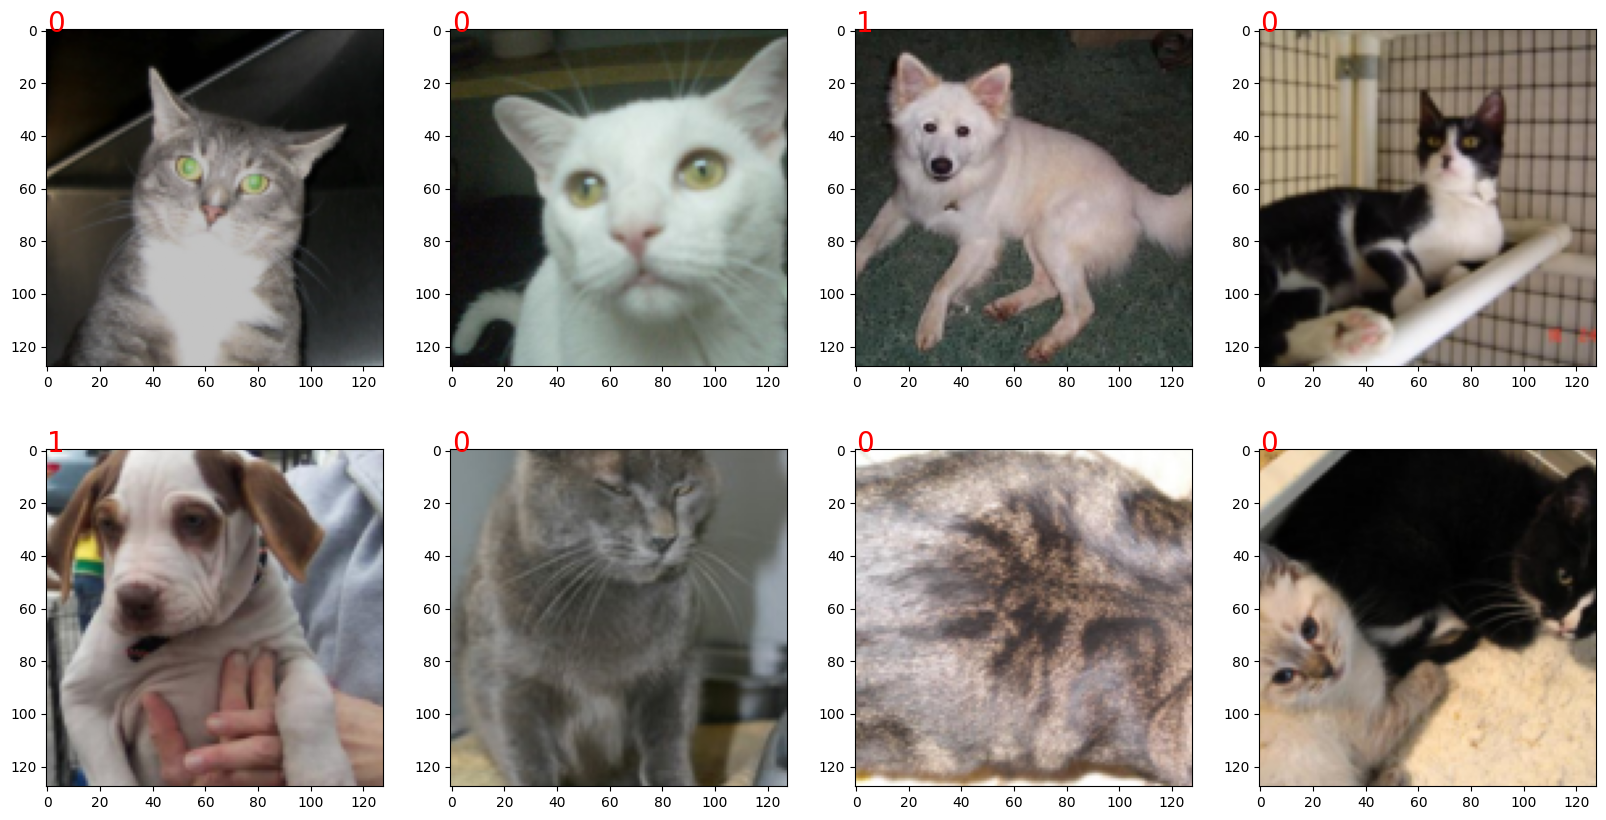

In [11]:
# Test data 의 시각화
f, axarr = plt.subplots(2,4, figsize=(20,10))
for i in range(2):
    for j in range(4):
        x, y = test_data[i*4+j]
        axarr[i,j].imshow(x.numpy().transpose(1,2,0))
        axarr[i,j].text(0.0, 0.5, str(round(y,2)), dict(size=20, color='red'))      # 라벨 표시

In [12]:
# 입력을 정규화 하기위한 Class
class NormalizeInput(nn.Module):
    def __init__(self, baseModel):
        """
        baseModel: the original ResNet model that needs to have it's inputs pre-processed
        """
        super(NormalizeInput, self).__init__()
        self.baseModel = baseModel
        self.mean = nn.Parameter(torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1), requires_grad=False)
        self.std = nn.Parameter(torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1), requires_grad=False)

    def forward(self, input):
        input = (input-self.mean)/self.std
        return self.baseModel(input)

In [ ]:
loss = nn.CrossEntropyLoss()                                    # 손실함수
vgg_model = torchvision.models.vgg16(pretrained=True)           # VGG 모델 사용 Pretrained = True 전이학습 적용
vgg_model.classifier[6] = nn.Linear(vgg_model.classifier[6].in_features, 2)
vgg_model = NormalizeInput(vgg_model)
vgg_model = vgg_model.to(device)                                # 에포크 10번
vgg_results = train_network(vgg_model, loss,train_loader, epochs=10 ,device=device, test_loader = test_loader, score_funcs={'Accuracy': accuracy_score})

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch:  10%|█         | 1/10 [01:24<12:44, 84.93s/it]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch:  20%|██        | 2/10 [02:50<11:21, 85.21s/it]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch:  30%|███       | 3/10 [04:16<09:58, 85.47s/it]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch:  40%|████      | 4/10 [05:42<08:34, 85.68s/it]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.war

In [15]:
final_epoch = vgg_results['epoch'].max()
final_acc = vgg_results[vgg_results['epoch'] == final_epoch]['test Accuracy'].values[0]
print(f'VGG Final Test Accuracy: {final_acc:.3f}%')

VGG Final Test Accuracy: 0.918%


In [16]:
# 사전 학습 된 모델 형식
# ResNet의 구조와 가중치 사용 warm start
# Fine-tuning 방식
# 전이학습 / Bigger Dataset
model_pretrained = torchvision.models.resnet18(pretrained=True) # ResNet 네트워크 모델 사용
model_pretrained.fc = nn.Linear(model_pretrained.fc.in_features, 2)
model_pretrained = NormalizeInput(model_pretrained)
warmstart_results = train_network(model_pretrained, loss, train_loader, epochs=10, device=device, test_loader=test_loader, score_funcs={'Accuracy': accuracy_score})

/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch:   0%|          | 0/10 [00:00<?, ?it/s]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch:  10%|█         | 1/10 [01:01<09:13, 61.52s/it]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlu

In [18]:
# 가중치 고정시키고 출력층 high level 부분만 학습
# 전이학습
# Conv layer => Frozen 
# FCLayer 들만 학습
# 데이터가 적을 경우 사용하는 방식 Small Dataset
model_frozen = torchvision.models.resnet18(pretrained=True)
for param in model_frozen.parameters():
    param.requires_grad = False         # 전체 파라미터 Freeze
model_frozen.fc = nn.Linear(model_frozen.fc.in_features, 2)             # 출력층 학습
model_frozen = NormalizeInput(model_frozen)
frozen_transfer_results = train_network(model_frozen, loss, train_loader, epochs=10, device=device, test_loader=test_loader, score_funcs={'Accuracy': accuracy_score})

/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch:   0%|          | 0/10 [00:00<?, ?it/s]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch:  10%|█         | 1/10 [00:58<08:43, 58.20s/it]/home/hadoop/anaconda3/envs/wookoo/lib/python3.10/site-packages/PIL/TiffImagePlu

Warmstart Accuracy: 0.960%
Frozen Accuracy: 0.942%


<Axes: xlabel='epoch', ylabel='test Accuracy'>

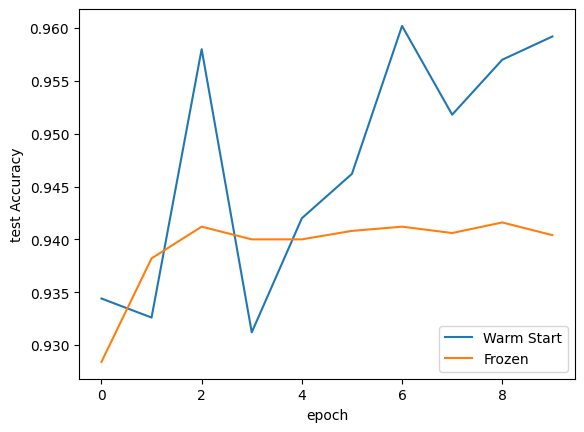

In [20]:
max_warmstart_acc = warmstart_results['test Accuracy'].max()
max_frozen_acc = frozen_transfer_results['test Accuracy'].max()

print(f"Warmstart Accuracy: {max_warmstart_acc:.3f}%")
print(f"Frozen Accuracy: {max_frozen_acc:.3f}%")

sns.lineplot(x='epoch', y='test Accuracy', data=warmstart_results, label='Warm Start')
sns.lineplot(x='epoch', y='test Accuracy', data=frozen_transfer_results, label='Frozen')